<a href="https://colab.research.google.com/github/CplSwofford/Signal_Systems/blob/Baseline0/ISS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# needed
import os
import re
import soundfile as sf
from IPython.display import Audio
from IPython.display import display
import numpy as np
# recommended ...
from scipy import signal
from scipy.io import wavfile
from scipy.fft import fft, ifft, fftfreq
import scipy.io
import matplotlib.pyplot as plt


# added by me (from iSS scripts):
from scipy.signal import spectrogram
import librosa


In [ ]:
# read data
login = "239468"
zip_file = "known" + ".zip"
for name in ("known.zip", "valid.zip", login + ".zip"):
  file = "https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/" + name
  !rm $name
  !wget $file
  !unzip -o -q $name

rm: cannot remove 'known.zip': No such file or directory
--2025-11-08 20:03:25--  https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/known.zip
Resolving www.fit.vut.cz (www.fit.vut.cz)... 147.229.9.65, 2001:67c:1220:809::93e5:941
Connecting to www.fit.vut.cz (www.fit.vut.cz)|147.229.9.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 210919709 (201M) [application/zip]
Saving to: ‘known.zip’

known.zip           100%[===================>] 201.15M  29.3MB/s    in 11s     

2025-11-08 20:03:37 (18.6 MB/s) - ‘known.zip’ saved [210919709/210919709]

rm: cannot remove 'valid.zip': No such file or directory
--2025-11-08 20:03:40--  https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/valid.zip
Resolving www.fit.vut.cz (www.fit.vut.cz)... 147.229.9.65, 2001:67c:1220:809::93e5:941
Connecting to www.fit.vut.cz (www.fit.vut.cz)|147.229.9.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7608498 (7.3M) [application/zip]
Saving to:

In [ ]:
# load the known data - the function returns a big matrix with all the signals
def load_data (S, dirname, count, no_samples):
  ii = 0
  for one in np.arange(count):
    S[ii], Fs = sf.read(dirname + "/" + str(one) + ".wav")
    ii = ii+1

Fs = 16000
# load known data
N_known = 706; duration_known = 10; no_samples_known = Fs * duration_known
known_signals=np.zeros([N_known, no_samples_known]); load_data(known_signals, "known", N_known, no_samples_known)
#display(Audio(known_signals[45], rate=Fs))

# load validation data
N_valid = 50; duration_valid = 5; no_samples_valid = Fs * duration_valid
valid_signals= np.zeros([N_valid, no_samples_valid]); load_data(valid_signals, "valid", N_valid, no_samples_valid)
#display(Audio(valid_signals[45], rate=Fs))

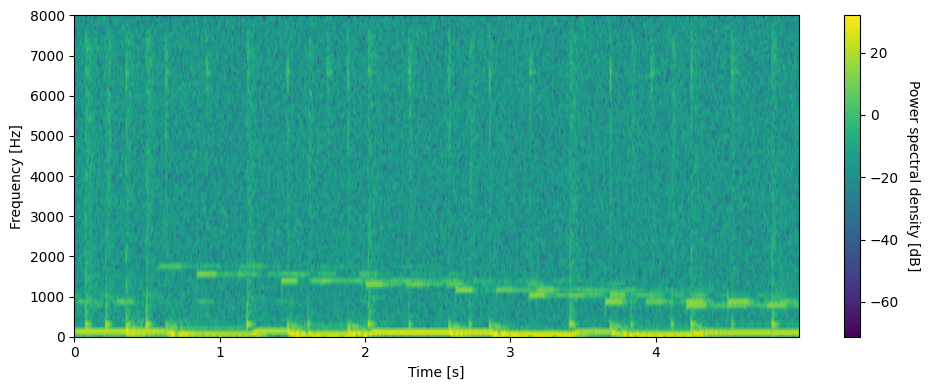

/tmp/ipython-input-2524398396.py:133: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  H = librosa.filters.mel(sr=fs, n_fft=nfft, n_mels=n_mels, fmin=fmin, fmax=fmax)  # (mels × bins)


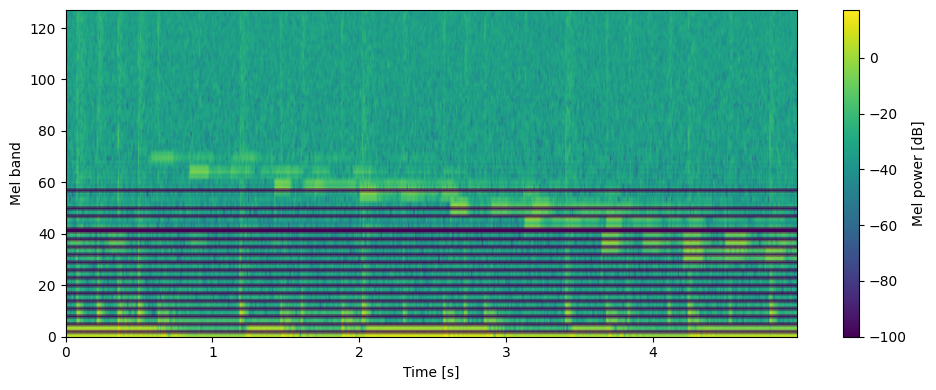

In [ ]:
# YOUR CODE COMES HERE ! Your task is to produce a matrix 50 x 706 with similarity measures

# COUNT number of sound clips
def sound_clips(folder):
    return sum(len(files) for _, _, files in os.walk(folder))


# GET number of sound clips
known_snound_clips_num = sound_clips("known")   #706
valid_snound_clips_num = sound_clips("valid")   #51
#print(known_snound_clips_num)
#print(valid_snound_clips_num)


# EMPTY Matrix - for saving comparison results
emptyMatrix_Valid_to_Known = np.zeros((valid_snound_clips_num, known_snound_clips_num), dtype=int)
#print(emptyMatrix_50Valid_to_706known.shape)



# GET info about
# sampling frequency = _FS
# number of samples = _samples
known_Fs, known_samples = wavfile.read(f"known/{0}.wav")    #16000, #160000
known_sample_len = known_samples.shape[0]
#print(known_Fs, known_samples.shape, known_samples.dtype)
#print(known_samples[:10])

valid_Fs, valid_samples = wavfile.read(f"valid/{0}.wav")    #16000, #80000
valid_sample_len = valid_samples.shape[0]
#print(valid_Fs, valid_samples.shape, valid_samples.dtype)
#print(valid_samples[:10])


# EMPTY Vectors - for saving normalized values
valid_vec = np.zeros((valid_snound_clips_num, valid_sample_len), dtype=np.float32)
known_vec = np.zeros((known_snound_clips_num, known_sample_len), dtype=np.float32)
#print(known_vec[:10])
#print(known_vec.shape)


# NORMALIAUTION function: from −32768 -> +32767  to -1 -> 1
def int16_to_unit_closed(x):
    xf = x.astype(np.float32)
    return np.where(xf < 0, xf / 32768.0, xf / 32767.0).astype(np.float32)


def norming(folder: str, n_files: int, out_mat: np.ndarray):
    for i in range(n_files):
        _, s = wavfile.read(f"{folder}/{i}.wav")
        """
        if getattr(s, "ndim", 1) == 2:   # stereo -> mono
            s = s.mean(axis=1)
            """
        out_mat[i, :] = int16_to_unit_closed(s)

# Calling
norming("valid", valid_snound_clips_num-1, valid_vec)   # -1 bcs of 51 ???
norming("known", known_snound_clips_num, known_vec)



# Framing:
def framing(a, frame_len, frame_shift=1):
    """
    from 03_spectral_2.ipynb   by profesor Černocký
    """
    a = np.ascontiguousarray(a)
    L = a.shape[0]
    if L < frame_len:
        return np.empty((0, frame_len), dtype=a.dtype)
    shape   = ((L - frame_len) // frame_shift + 1, frame_len) + a.shape[1:]
    strides = (a.strides[0]*frame_shift, a.strides[0]) + a.strides[1:]
    return np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides)


def spectrogram(x, window, noverlap=None, nfft=None):
    """
    from 03_spectral_2.ipynb   by profesor Černocký
    """
    if np.isscalar(window):
        window = np.hamming(int(window))
    if noverlap is None:
        noverlap = window.size // 2
    if nfft is None:
        nfft = window.size

    hop = window.size - noverlap
    Xfrm = framing(x, window.size, hop)
    X = np.fft.rfft(Xfrm * window[None, :], n=nfft, axis=1)
    return X


def show_spectrogram(X, fs, nfft, frame_shift):
    """
    from 03_spectral_2.ipynb   by profesor Černocký
    """
    # osy
    f = np.arange(0, nfft//2 + 1) * fs / nfft
    t = np.arange(0, X.shape[0]) * frame_shift / fs

    # výpočet logaritmického výkonového spektra
    sgr_log = 10 * np.log10(np.real(np.conj(X.T) * X.T) + 1e-20)

    # zobrazení
    plt.figure(figsize=(10,4))
    plt.pcolormesh(t, f, sgr_log, shading='gouraud', cmap="viridis")
    plt.xlabel('Time [s]')
    plt.ylabel('Frequency [Hz]')
    cbar = plt.colorbar()
    cbar.set_label('Power spectral density [dB]', rotation=270, labelpad=15)
    plt.tight_layout()
    plt.show()



N = 256
Nfft = 256
overlap = 128
hop = N - overlap

X = spectrogram(valid_vec[0], N, overlap, Nfft)
show_spectrogram (X, valid_Fs, Nfft, hop)

# After scaling still same, just check
display(Audio(valid_vec[0], rate=valid_Fs))
display(Audio(f"valid/{0}.wav", rate=valid_Fs))


#########################################################################################
def mel_db(X, fs, nfft, n_mels=64, fmin=1000, fmax=6000, eps=1e-10):
    S = (np.abs(X)**2).T                                                             # (bins × frames)
    H = librosa.filters.mel(sr=fs, n_fft=nfft, n_mels=n_mels, fmin=fmin, fmax=fmax)  # (mels × bins)
    return 10*np.log10(H @ S + eps)

M = mel_db(X, fs=valid_Fs, nfft=Nfft, n_mels=128, fmin=100, fmax=6000)

t = np.arange(M.shape[1]) * (hop / valid_Fs)
y = np.arange(M.shape[0])
plt.figure(figsize=(10,4))
plt.pcolormesh(t, y, M, shading='gouraud')
plt.xlabel('Time [s]')
plt.ylabel('Mel band')
plt.colorbar(label='Mel power [dB]')
plt.tight_layout()
#########################################################################################


n_mels = 64
fmin, fmax = 100, 6000


##########################################################################################
def clip_to_embedding(x):
    X = spectrogram(x, np.hanning(N), overlap, Nfft)   # komplexní STFT (frames × bins)
    M = mel_db(X, fs=Fs, nfft=Nfft, n_mels=n_mels, fmin=fmin, fmax=fmax)  # (mels × frames), dB
    emb = M.mean(axis=1)  # průměr přes čas → (mels,)
    return emb

# 2) Předpočítej KNOWN embeddingy (706 × n_mels)
known_emb = np.vstack([clip_to_embedding(known_vec[j]) for j in range(known_vec.shape[0])])  # shape (706, n_mels)
known_norm = np.linalg.norm(known_emb, axis=1, keepdims=True) + 1e-12  # (706,1)


##########################################################################################



N_valid = 50

def compute_similarity_matrix(N_valid, N_known):
  # complete stupid solution just for testing the evaluation ...
  # the full version will probably have more arguments !
  similarities = np.random.uniform( 0, 1, (N_valid, N_known))

  for i in range(N_valid):
      v = clip_to_embedding(valid_vec[i])                      # (n_mels,)
      vnorm = np.linalg.norm(v) + 1e-12
      sims = (known_emb @ v) / (known_norm.ravel() * vnorm)    # (706,)
      similarities[i, :] = sims

  return similarities




In [ ]:
# evaluation - the function produces Top-1 and Top-5 accuracy on validation data
def eval(scores, key):
  indices = np.flip(np.argsort(scores), axis=-1) # we want highest to lowest ...
  #print(scores[0,key[0]], key[0], indices)
  top1acc = np.sum(key == indices[:,0]) / indices.shape[0]
  top5acc = 0
  for ii in range(5):
    top5acc += np.sum(key == indices[:,ii])
  top5acc /=  indices.shape[0]
  return top1acc, top5acc

key = np.loadtxt("valid/key.txt", delimiter = ',', usecols=(1), dtype ='int')



N_valid, N_known = 50, 706
scores_matrix = compute_similarity_matrix(N_valid, N_known)
key_used = key[:scores_matrix.shape[0]]
top1, top5 = eval(scores_matrix, key_used)
print(f"Top-1: {top1*100:.1f}%  |  Top-5: {top5*100:.1f}%")


np.savetxt("eval.txt", scores_matrix)
print(scores_matrix.shape[0], scores_matrix.shape[1])

Top-1: 56.0%  |  Top-5: 64.0%
50 706
